In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


# MEMBACA GAMBAR

In [2]:
img = cv2.imread('nama rendy.jpeg')

# Konversi BGR ke RGB

In [3]:
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# DETEKSI WARNA HSV

In [4]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# AMBANG BATAS WARNA

In [5]:
# MERAH
lower_red1 = np.array([0, 100, 100])
upper_red1 = np.array([10, 255, 255])

lower_red2 = np.array([160, 100, 100])
upper_red2 = np.array([180, 255, 255])

# HIJAU
lower_green = np.array([40, 50, 50])
upper_green = np.array([80, 255, 255])

# BIRU
lower_blue = np.array([100, 50, 50])
upper_blue = np.array([140, 255, 255])

# MASKING WARNA

In [6]:
mask_red1 = cv2.inRange(hsv, lower_red1, upper_red1)
mask_red2 = cv2.inRange(hsv, lower_red2, upper_red2)
mask_red = mask_red1 + mask_red2

mask_green = cv2.inRange(hsv, lower_green, upper_green)
mask_blue = cv2.inRange(hsv, lower_blue, upper_blue)

# HASIL DETEKSI WARNA

In [7]:
# =========================
# MEMBUAT GAMBAR GRAYSCALE
# =========================

gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)

# Ubah grayscale ke RGB
gray_rgb = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)

# =========================
# HASIL DETEKSI WARNA
# =========================

# MERAH
result_red = gray_rgb.copy()
result_red[mask_red > 0] = rgb[mask_red > 0]

# HIJAU
result_green = gray_rgb.copy()
result_green[mask_green > 0] = rgb[mask_green > 0]

# BIRU
result_blue = gray_rgb.copy()
result_blue[mask_blue > 0] = rgb[mask_blue > 0]

# =========================
# KATEGORI WARNA
# =========================

# NONE
none = np.zeros_like(gray)

# BLUE
blue_only = cv2.bitwise_and(gray, gray, mask=mask_blue)

# RED-BLUE
mask_red_blue = mask_red + mask_blue
red_blue = cv2.bitwise_and(gray, gray, mask=mask_red_blue)

# RED-GREEN-BLUE
mask_all = mask_red + mask_green + mask_blue
all_colors = cv2.bitwise_and(gray, gray, mask=mask_all)

# MENAMPILKAN HASIL

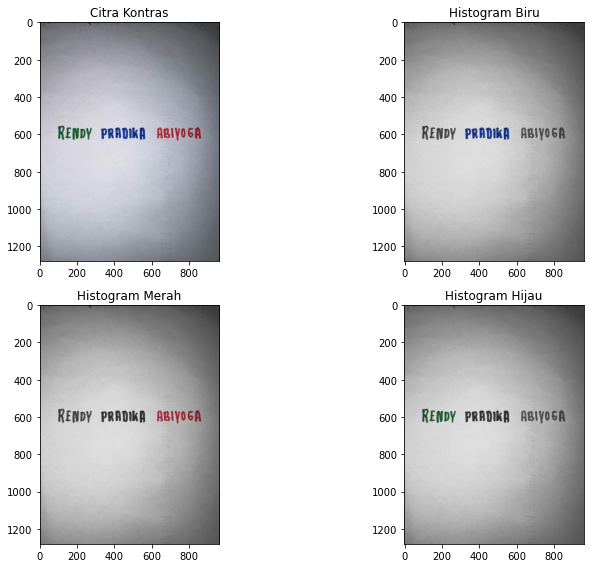

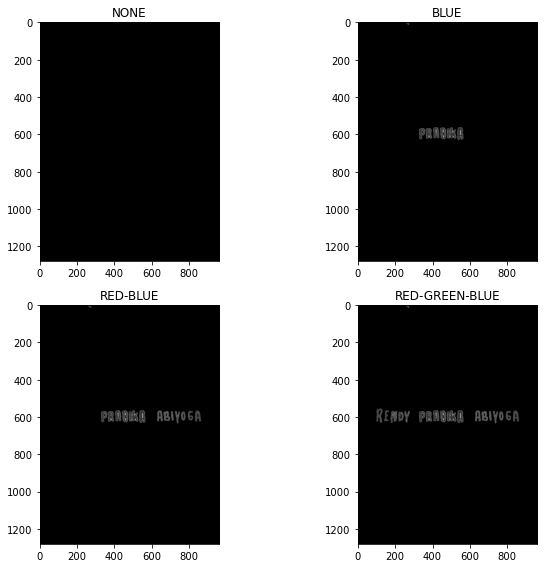

In [8]:
plt.figure(figsize=(12,8))



# Citra Asli

plt.subplot(2,2,1)

plt.imshow(rgb)

plt.title("Citra Kontras")




# Histogram Biru

plt.subplot(2,2,2)

plt.imshow(result_blue)

plt.title("Histogram Biru")



# Histogram Merah

plt.subplot(2,2,3)

plt.imshow(result_red)

plt.title("Histogram Merah")



# Histogram Hijau

plt.subplot(2,2,4)

plt.imshow(result_green)

plt.title("Histogram Hijau")


plt.tight_layout()

plt.show()


# =========================
# MENAMPILKAN DETEKSI WARNA & HISTOGRAM
# =========================

plt.figure(figsize=(12,10))

# 1. Citra Kontras (Sebagai Referensi)
plt.subplot(2,2,1)
plt.imshow(rgb)
plt.title("Citra Kontras")

# 2. Histogram Biru (Hanya menghitung area yang terkena mask_blue)
plt.subplot(2,2,2)
# Gunakan mask agar yang dihitung hanya piksel warna biru saja
hist_blue = cv2.calcHist([rgb], [2], mask_blue, [256], [1, 256])
plt.plot(hist_blue, color='blue')
plt.title("Histogram Biru (Hanya Objek)")
plt.xlim([1, 256]) # Memulai dari 1 agar warna hitam background tidak mengganggu

# 3. Histogram Merah (Hanya menghitung area yang terkena mask_red)
plt.subplot(2,2,3)
hist_red = cv2.calcHist([rgb], [0], mask_red, [256], [1, 256])
plt.plot(hist_red, color='red')
plt.title("Histogram Merah (Hanya Objek)")
plt.xlim([1, 256])

# 4. Histogram Hijau (Hanya menghitung area yang terkena mask_green)
plt.subplot(2,2,4)
hist_green = cv2.calcHist([rgb], [1], mask_green, [256], [1, 256])
plt.plot(hist_green, color='green')
plt.title("Histogram Hijau (Hanya Objek)")
plt.xlim([1, 256])

plt.tight_layout()
plt.show()

# =========================
# MENAMPILKAN KATEGORI
# =========================

plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.imshow(none, cmap='gray')
plt.title("NONE")

plt.subplot(2,2,2)
plt.imshow(blue_only, cmap='gray')
plt.title("BLUE")

plt.subplot(2,2,3)
plt.imshow(red_blue, cmap='gray')
plt.title("RED-BLUE")

plt.subplot(2,2,4)
plt.imshow(all_colors, cmap='gray')
plt.title("RED-GREEN-BLUE")

plt.tight_layout()
plt.show()



# HISTOGRAM

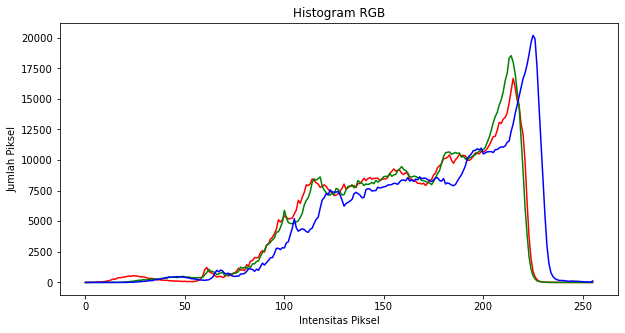

In [9]:
color = ('r', 'g', 'b')

plt.figure(figsize=(10,5))

for i, col in enumerate(color):
    hist = cv2.calcHist([rgb], [i], None, [256], [0,256])
    plt.plot(hist, color=col)

plt.title("Histogram RGB")
plt.xlabel("Intensitas Piksel")
plt.ylabel("Jumlah Piksel")

plt.show()